# Mengimport Dataset

Nama : Khalis Tofari

In [1]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "data_center_hybrid.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ashyou09/global-data-center-and-ai-waterelectricity-usage",
  file_path,
)

print("First 5 records:", df.head())

C:\Users\user\.conda\envs\projekML-GDGoC\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    Year  Facility_ID               Facility_Name Owner_Company    City  \
0  2019  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
1  2020  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
2  2021  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
3  2022  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
4  2023  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   

  Country        Facility_Type  Estimated_Capacity_MW    PUE  \
0   Spain  Enterprise/Standard                   6.24  1.975   
1   Spain  Enterprise/Standard                   6.36  1.967   
2   Spain  Enterprise/Standard                   6.47  1.928   
3   Spain  Enterprise/Standard                   6.59  1.897   
4   Spain  Enterprise/Standard                   6.70  1.869   

  Cooling_System_Type  WUE_L_per_kWh  Daily_Electricity_Usage_MWh  \
0         Evaporative          1.481                       183.62   
1         Evapo

# Fase Exploratory Data Analysis

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  str    
 2   Facility_Name                  126770 non-null  str    
 3   Owner_Company                  126770 non-null  str    
 4   City                           126770 non-null  str    
 5   Country                        126770 non-null  str    
 6   Facility_Type                  126770 non-null  str    
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  str    
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons      126770 non

In [3]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


In [4]:
print("Jumlah baris duplikat : ", df.duplicated().sum())

Jumlah baris duplikat :  0


## Visualisasi dengna Matplotlib

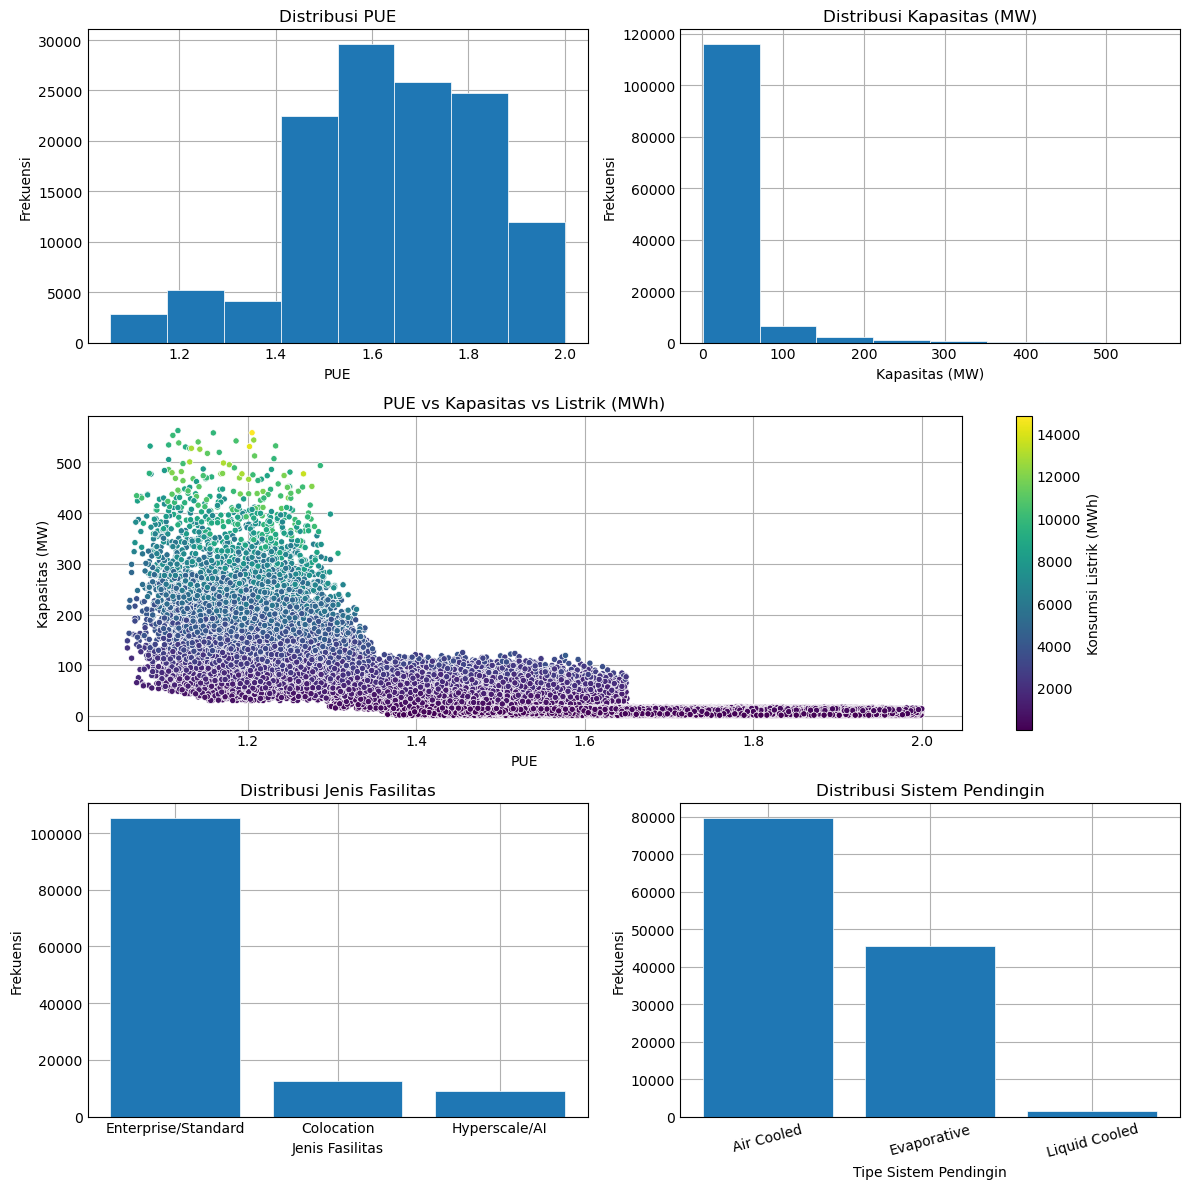

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

x = df['PUE']
y = df['Estimated_Capacity_MW']
target = df['Daily_Electricity_Usage_MWh']

fig = plt.figure(figsize=(12, 12))

gs = fig.add_gridspec(3, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

# Grafik ax1 (Histogram PUE)
ax1.hist(x, bins=8, linewidth=0.5, edgecolor="white")
ax1.set_title('Distribusi PUE')
ax1.set_xlabel('PUE')
ax1.set_ylabel('Frekuensi')

# Grafik ax2 (Histogram Kapasitas)
ax2.hist(y, bins=8, linewidth=0.5, edgecolor="white")
ax2.set_title('Distribusi Kapasitas (MW)')
ax2.set_xlabel('Kapasitas (MW)')
ax2.set_ylabel('Frekuensi')

# Grafik ax3
scatter_plot = ax3.scatter(x, y, s=20, linewidth=0.5, edgecolor="white", marker="o", c=target, cmap="viridis")
ax3.set_title('PUE vs Kapasitas vs Listrik (MWh)')
ax3.set_xlabel('PUE')
ax3.set_ylabel('Kapasitas (MW)')

cbar = fig.colorbar(scatter_plot, ax=ax3)
cbar.set_label('Konsumsi Listrik (MWh)')

# Grafik ax4 (Distribusi Jenis Fasilitas - Terurut Otomatis)
facility_counts = df['Facility_Type'].value_counts()
ax4.bar(facility_counts.index, facility_counts.values, linewidth=0.5, edgecolor="white")
ax4.set_title('Distribusi Jenis Fasilitas')
ax4.set_xlabel('Jenis Fasilitas')
ax4.set_ylabel('Frekuensi')

# Grafik ax5 (Distribusi Jenis Sistem Pendingin - Terurut Otomatis)
cooling_counts = df['Cooling_System_Type'].value_counts()
ax5.bar(cooling_counts.index, cooling_counts.values, linewidth=0.5, edgecolor="white")
ax5.set_title('Distribusi Sistem Pendingin')
ax5.set_xlabel('Tipe Sistem Pendingin')
ax5.set_ylabel('Frekuensi')

ax5.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [6]:
print("Memastikan tidak ada rasio PUE yang bernilai sama atau lebih kecil dari 1.0, karena masih teoritikal dan sangat kecil kemungkinannya ada yang mencapai efektivitas energi 100%")
df.loc[df['PUE'] <= 1.0, ['PUE']].count()

Memastikan tidak ada rasio PUE yang bernilai sama atau lebih kecil dari 1.0, karena masih teoritikal dan sangat kecil kemungkinannya ada yang mencapai efektivitas energi 100%


PUE    0
dtype: int64

Dari fase EDA di atas diketahui bahwa tidak ada data yang anomali. Dan untuk model yang saya pilih ini sifatnya kebal terhadap outlier. jadi pemrosesan terhadap outlier dan bentuk distribusi data tidak terlalu berpengaruh terhadap model.

# Pembagian data

In [7]:
from sklearn.model_selection import train_test_split

fitur_pilihan = [
    'PUE', 
    'Estimated_Capacity_MW', 
    'WUE_L_per_kWh',                
    'Year', 
    'Facility_Type', 
    'Cooling_System_Type', 
    'Surrounding_Water_Stress_Tier'
]

X = df[fitur_pilihan]
y = df['Daily_Electricity_Usage_MWh']

# One-Hot Encoding
kolom_kategori = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']
X_encoded = pd.get_dummies(X, columns=kolom_kategori, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=69)

print("Fitur berhasil diproses. Jumlah kolom saat ini:", X_encoded.shape[1])

Fitur berhasil diproses. Jumlah kolom saat ini: 10


# Training Model

Untuk library, saya memakai Scikit-Learn

## Model HistGradientBoostingRegressor

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Inisialisasi Model HistGradientBoosting
hgb_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=69
)

# Proses Pelatihan (Training)
hgb_model.fit(X_train, y_train)

# Prediksi menggunakan data Test
y_pred_hgb = hgb_model.predict(X_test)

# Evaluasi Kinerja Model
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
r2_hgb = r2_score(y_test, y_pred_hgb)

print("Evaluasi Model HistGradientBoostingRegressor:")
print(f"Mean Absolute Error (MAE) : {mae_hgb:.2f} MWh")
print(f"R-squared (R2)            : {r2_hgb:.4f}")

Evaluasi Model HistGradientBoostingRegressor:
Mean Absolute Error (MAE) : 71.61 MWh
R-squared (R2)            : 0.9723


## Model RandomForestRegressor

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Inisialisasi Model Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=69,
    n_jobs=-1
)

# Pelatihan Model
rf_model.fit(X_train, y_train)

# Prediksi dan Hitung Metrik
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

## Tabel Perbandingan Evaluasi untuk Kedua Model

In [10]:
mse_hgb = mean_squared_error(y_test, y_pred_hgb)
rmse_hgb = np.sqrt(mse_hgb)

# Membuat DataFrame Tabel Evaluasi Akhir
df_evaluasi = pd.DataFrame({
    'Model / Algorithm': [
        'HistGradientBoosting',
        'Random Forest Regressor'
    ],
    'MAE': [mae_hgb, mae_rf],
    'MSE': [mse_hgb, mse_rf],
    'RMSE': [rmse_hgb, rmse_rf],
    'R2 Score': [r2_hgb, r2_rf]
})

# Urutkan berdasarkan R2 Score dari yang paling tinggi ke rendah
df_evaluasi = df_evaluasi.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

df_evaluasi

,Model / Algorithm,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,78.592300,30325.896877,174.143323,0.972352
1,HistGradientBoosting,71.613211,30402.070451,174.361895,0.972283


In [11]:
import joblib

nama_file_hgb = 'model_data_center_hgb.joblib'
joblib.dump(hgb_model, nama_file_hgb)
print(f"Model HistGradientBoosting berhasil disimpan sebagai: {nama_file_hgb}")

nama_file_rf = 'model_data_center_rf.joblib'
joblib.dump(rf_model, nama_file_rf)
print(f"Model Random Forest berhasil disimpan sebagai: {nama_file_rf}")

joblib.dump(list(X_encoded.columns), 'model_features.joblib')
print("Daftar kolom sukses disimpan!")

Model HistGradientBoosting berhasil disimpan sebagai: model_data_center_hgb.joblib
Model Random Forest berhasil disimpan sebagai: model_data_center_rf.joblib
Daftar kolom sukses disimpan!
